Loaded 105 snapshots across 225 financial nodes.
Training GAE on 76 historical snapshots (2000-Q1 to 2018-Q4)...
Epoch 001 | Train Reconstruction Loss: 1.3698
Epoch 020 | Train Reconstruction Loss: 1.0954
Epoch 040 | Train Reconstruction Loss: 1.0920
Epoch 060 | Train Reconstruction Loss: 1.0906
Epoch 080 | Train Reconstruction Loss: 1.0890
Epoch 100 | Train Reconstruction Loss: 1.0852


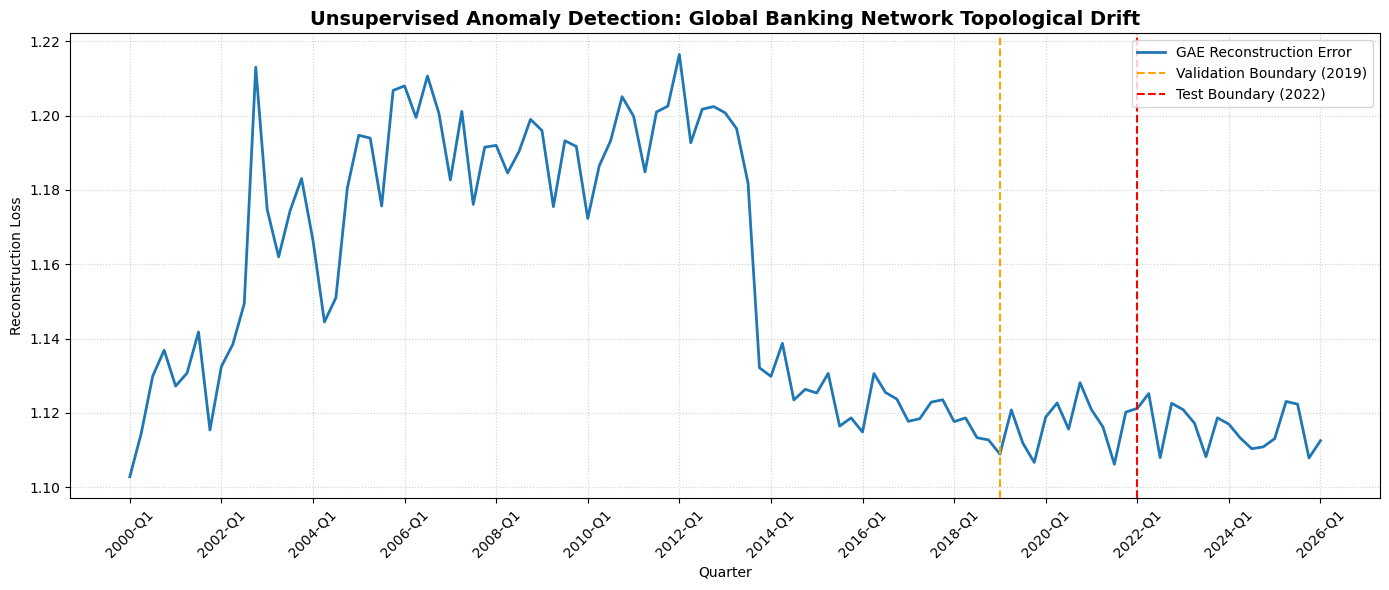

Saved anomaly outputs to data/processed/gae_systemic_anomalies.csv


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GAE
from torch_geometric.utils import negative_sampling, to_undirected
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ==========================================
# 1. Load Data and Metadata
# ==========================================
PROCESSED_DIR = Path("../data/processed")
graph_snapshots = torch.load(PROCESSED_DIR / "temporal_graph_sequence.pt", weights_only=False)
node_index = pd.read_csv(PROCESSED_DIR / "bis_cbs_node_index.csv")

NUM_NODES = len(node_index)  # 225 nodes
print(f"Loaded {len(graph_snapshots)} snapshots across {NUM_NODES} financial nodes.")

# ==========================================
# 2. Enrich Snapshots with Node Features
# ==========================================
# Construct node-level feature vectors per snapshot:
# [In-Strength, Out-Strength, In-Degree, Out-Degree]
for graph in graph_snapshots:
    src, dst = graph.edge_index[0], graph.edge_index[1]
    weights = graph.edge_attr.view(-1)
    
    out_degree = torch.zeros(NUM_NODES, dtype=torch.float)
    in_degree = torch.zeros(NUM_NODES, dtype=torch.float)
    out_strength = torch.zeros(NUM_NODES, dtype=torch.float)
    in_strength = torch.zeros(NUM_NODES, dtype=torch.float)
    
    out_degree.scatter_add_(0, src, torch.ones_like(src, dtype=torch.float))
    in_degree.scatter_add_(0, dst, torch.ones_like(dst, dtype=torch.float))
    out_strength.scatter_add_(0, src, weights)
    in_strength.scatter_add_(0, dst, weights)
    
    # Feature matrix: [225, 4]
    x = torch.stack([out_strength, in_strength, out_degree, in_degree], dim=1)
    # Log-transform and normalize for neural stability
    graph.x = torch.log1p(torch.clamp(x, min=0.0))
    graph.num_nodes = NUM_NODES

# ==========================================
# 3. Define Graph Autoencoder Architecture
# ==========================================
class GCNEncoder(nn.Module):
    def __init__(self, in_channels, hidden_dim, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv2(x, edge_index)

IN_DIM = 4
HIDDEN_DIM = 16
LATENT_DIM = 8

encoder = GCNEncoder(IN_DIM, HIDDEN_DIM, LATENT_DIM)
gae_model = GAE(encoder)
optimizer = torch.optim.Adam(gae_model.parameters(), lr=0.01, weight_decay=1e-4)

# ==========================================
# 4. Train Strictly on Training Regimes
# ==========================================
train_snapshots = [g for g in graph_snapshots if int(g.period[:4]) <= 2018]
print(f"Training GAE on {len(train_snapshots)} historical snapshots (2000-Q1 to 2018-Q4)...")

gae_model.train()
EPOCHS = 100

for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0
    for graph in train_snapshots:
        optimizer.zero_grad()
        z = gae_model.encode(graph.x, graph.edge_index)
        
        # Self-supervised link reconstruction loss
        loss = gae_model.recon_loss(z, graph.edge_index)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    if epoch % 20 == 0 or epoch == 1:
        avg_loss = total_loss / len(train_snapshots)
        print(f"Epoch {epoch:03d} | Train Reconstruction Loss: {avg_loss:.4f}")

# ==========================================
# 5. Compute Systemic Anomaly Trajectory
# ==========================================
gae_model.eval()
anomaly_records = []

with torch.no_grad():
    for graph in graph_snapshots:
        z = gae_model.encode(graph.x, graph.edge_index)
        
        # Global Reconstruction Loss for the quarter
        loss = gae_model.recon_loss(z, graph.edge_index).item()
        
        # Node-level reconstruction error
        adj_recon = torch.sigmoid(torch.matmul(z, z.t()))
        src, dst = graph.edge_index
        true_link_errors = (1.0 - adj_recon[src, dst]) ** 2
        
        node_error = torch.zeros(NUM_NODES)
        node_error.scatter_add_(0, src, true_link_errors)
        top_node_idx = torch.argmax(node_error).item()
        top_country = node_index.loc[node_index['node_id'] == top_node_idx, 'node_name'].values[0]
        
        anomaly_records.append({
            'period': graph.period,
            'year': int(graph.period[:4]),
            'reconstruction_error': loss,
            'top_anomalous_node': top_country,
            'regime': 'Train' if int(graph.period[:4]) <= 2018 else ('Val' if int(graph.period[:4]) <= 2021 else 'Test')
        })

df_anomalies = pd.DataFrame(anomaly_records)

# ==========================================
# 6. Visualize Systemic Reconstruction Error
# ==========================================
plt.figure(figsize=(14, 6))
plt.plot(df_anomalies['period'], df_anomalies['reconstruction_error'], color='#1f77b4', lw=2, label='GAE Reconstruction Error')

# Highlight Regimes
val_start = df_anomalies[df_anomalies['regime'] == 'Val'].index[0]
test_start = df_anomalies[df_anomalies['regime'] == 'Test'].index[0]

plt.axvline(x=val_start, color='orange', linestyle='--', label='Validation Boundary (2019)')
plt.axvline(x=test_start, color='red', linestyle='--', label='Test Boundary (2022)')

# Formatting
step = 8
plt.xticks(ticks=range(0, len(df_anomalies), step), labels=df_anomalies['period'].iloc[::step], rotation=45)
plt.title("Unsupervised Anomaly Detection: Global Banking Network Topological Drift", fontweight='bold', fontsize=14)
plt.xlabel("Quarter")
plt.ylabel("Reconstruction Loss")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Save anomaly outputs for the dashboard
df_anomalies.to_csv(PROCESSED_DIR / "gae_systemic_anomalies.csv", index=False)
print("Saved anomaly outputs to data/processed/gae_systemic_anomalies.csv")